In [1]:
import pandas as pd 
import numpy as np
panel_df = pd.read_csv(r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\raw\nifty100_panel.csv")
panel_df.head()

,Date,Ticker,Open,High,Low,Close,Volume
0,2015-01-01,HDFCLIFE.NS,NaN,NaN,NaN,NaN,NaN
1,2015-01-01,MUTHOOTFIN.NS,157.411502,174.036082,156.608382,172.188904,1116007.0
2,2015-01-01,ADANIENSOL.NS,NaN,NaN,NaN,NaN,NaN
3,2015-01-01,UNITDSPR.NS,544.422864,553.891497,539.526975,551.923340,451940.0
4,2015-01-01,BANKBARODA.NS,180.050846,181.501113,178.825612,180.542603,1756690.0


In [2]:
panel_df.shape

(256568, 7)

In [3]:
panel_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 256568 entries, 0 to 256567
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Date    256568 non-null  str    
 1   Ticker  256568 non-null  str    
 2   Open    221602 non-null  float64
 3   High    221602 non-null  float64
 4   Low     221602 non-null  float64
 5   Close   221602 non-null  float64
 6   Volume  221602 non-null  float64
dtypes: float64(5), str(2)
memory usage: 13.7 MB


In [4]:
print(panel_df["Date"].min())
print(panel_df["Date"].max())

2015-01-01
2024-12-31


In [5]:
coverage = (
    panel_df
    .groupby("Ticker")
    .size()
    .sort_values()
)

coverage.head(104)

Ticker
ABB.NS           2467
ADANIENSOL.NS    2467
ADANIENT.NS      2467
ADANIGREEN.NS    2467
ADANIPORTS.NS    2467
                 ... 
UNITDSPR.NS      2467
VBL.NS           2467
VEDL.NS          2467
WIPRO.NS         2467
ZYDUSLIFE.NS     2467
Length: 104, dtype: int64

In [6]:
coverage.describe()

count     104.0
mean     2467.0
std         0.0
min      2467.0
25%      2467.0
50%      2467.0
75%      2467.0
max      2467.0
dtype: float64

In [7]:
panel_df["Volume"].describe()

count    2.216020e+05
mean     9.399020e+06
std      2.288483e+07
min      0.000000e+00
25%      7.472525e+05
50%      2.769548e+06
75%      9.464393e+06
max      1.210999e+09
Name: Volume, dtype: float64

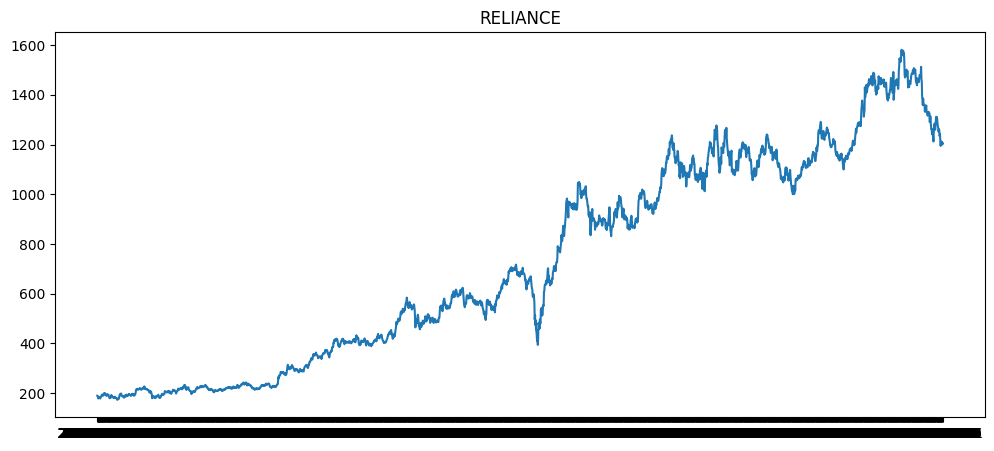

In [8]:
import matplotlib.pyplot as plt
reliance = panel_df[
    panel_df["Ticker"] == "RELIANCE.NS"
]

plt.figure(figsize=(12,5))
plt.plot(reliance["Date"], reliance["Close"])
plt.title("RELIANCE")
plt.show()

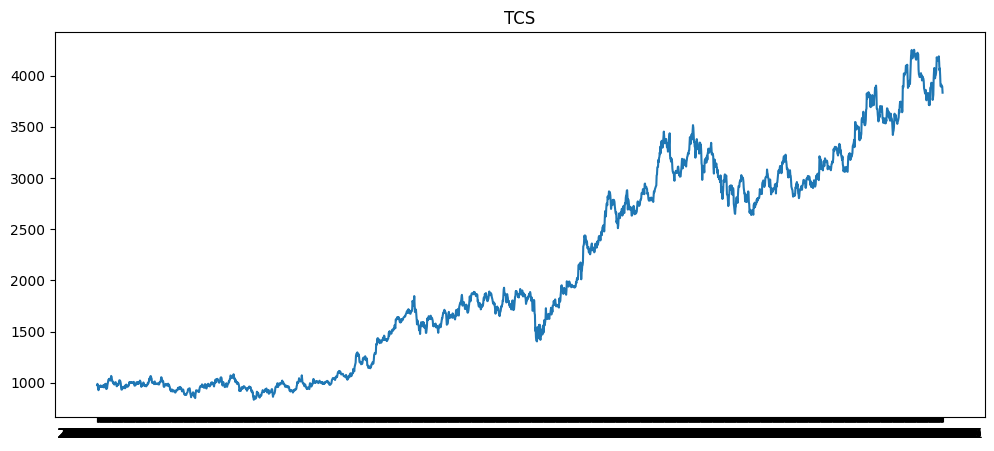

In [9]:
tcs = panel_df[
    panel_df["Ticker"] == "TCS.NS"
]

plt.figure(figsize=(12,5))
plt.plot(tcs["Date"], tcs["Close"])
plt.title("TCS")
plt.show()

In [10]:
panel_df["Close"].describe()

count    221602.000000
mean       1350.554548
std        3130.795229
min           3.090000
25%         143.245544
50%         479.347717
75%        1143.729340
max       38276.093750
Name: Close, dtype: float64

In [11]:
panel_df[["Close", "Volume"]].head()

,Close,Volume
0,NaN,NaN
1,172.188904,1116007.0
2,NaN,NaN
3,551.923340,451940.0
4,180.542603,1756690.0


In [12]:
panel_df = panel_df.sort_values(["Ticker", "Date"])

In [13]:
panel_df["daily_return"] = (panel_df.groupby("Ticker")["Close"].pct_change())

In [14]:
panel_df.head()

,Date,Ticker,Open,High,Low,Close,Volume,daily_return
29,2015-01-01,ABB.NS,1107.926354,1152.027107,1101.001864,1126.536133,111455.0,NaN
133,2015-01-02,ABB.NS,1137.139400,1145.145911,1111.388771,1114.851074,50549.0,-0.010373
237,2015-01-05,ABB.NS,1123.506766,1137.355748,1112.254309,1115.110718,39947.0,0.000233
341,2015-01-06,ABB.NS,1113.509214,1114.807592,1083.084497,1104.983398,64200.0,-0.009082
445,2015-01-07,ABB.NS,1114.764588,1118.226891,1084.642810,1089.057251,45574.0,-0.014413


In [15]:
panel_df["daily_return"].describe(
    
)

count    221505.000000
mean          0.000938
std           0.021808
min          -0.387493
25%          -0.009865
50%           0.000328
75%           0.010980
max           0.462011
Name: daily_return, dtype: float64

Text(0.5, 1.0, 'Daily returns')

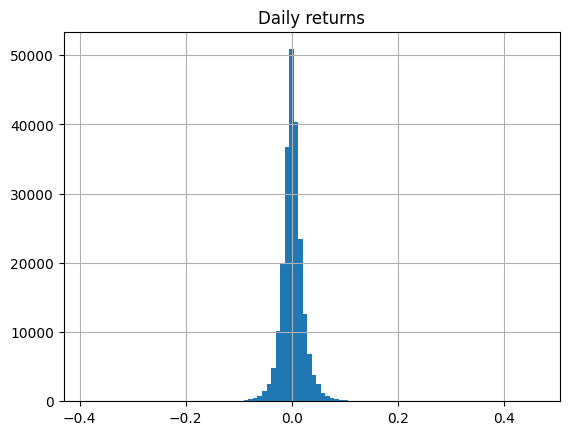

In [16]:
panel_df["daily_return"].hist(bins=100)
plt.title("Daily returns")

In [17]:
missing_by_stock = (
    panel_df
    .groupby("Ticker")
    .apply(
        lambda x: x["Close"].isna().mean()
    )
    .sort_values(ascending=False)
)

missing_by_stock.head(20)

Ticker
ENRIN.NS         1.000000
DUMMYVEDL2.NS    1.000000
DUMMYVEDL4.NS    1.000000
DUMMYVEDL1.NS    1.000000
DUMMYVEDL3.NS    1.000000
TMCV.NS          1.000000
TATACAP.NS       1.000000
HYUNDAI.NS       0.980543
JIOFIN.NS        0.864208
ETERNAL.NS       0.655452
LODHA.NS         0.628699
IRFC.NS          0.607621
MAZDOCK.NS       0.576814
MAXHEALTH.NS     0.562627
HDFCAMC.NS       0.360357
ADANIGREEN.NS    0.346169
HAL.NS           0.324281
HDFCLIFE.NS      0.287799
SBILIFE.NS       0.274828
DMART.NS         0.220916
dtype: float64

In [18]:
bad_tickers = missing_by_stock[
    missing_by_stock == 1
].index.tolist()

bad_tickers

['ENRIN.NS',
 'DUMMYVEDL2.NS',
 'DUMMYVEDL4.NS',
 'DUMMYVEDL1.NS',
 'DUMMYVEDL3.NS',
 'TMCV.NS',
 'TATACAP.NS']

In [19]:
panel_df = panel_df[
    ~panel_df["Ticker"].isin(bad_tickers)
]

In [20]:
coverage = (
    panel_df
    .groupby("Ticker")["Close"]
    .count()
    .sort_values()
)

coverage.head(20)

Ticker
HYUNDAI.NS         48
JIOFIN.NS         335
ETERNAL.NS        850
LODHA.NS          916
IRFC.NS           968
MAZDOCK.NS       1044
MAXHEALTH.NS     1079
HDFCAMC.NS       1578
ADANIGREEN.NS    1613
HAL.NS           1667
HDFCLIFE.NS      1757
SBILIFE.NS       1789
DMART.NS         1922
VBL.NS           2013
LTM.NS           2085
INDIGO.NS        2255
ADANIENSOL.NS    2323
BANKBARODA.NS    2467
BEL.NS           2467
BOSCHLTD.NS      2467
Name: Close, dtype: int64

In [21]:
panel_df = panel_df.dropna(
    subset=["Close"]
)


In [22]:
panel_df.isna().sum()

Date             0
Ticker           0
Open             0
High             0
Low              0
Close            0
Volume           0
daily_return    97
dtype: int64

In [23]:
panel_df["daily_return"].isna()

29         True
133       False
237       False
341       False
445       False
          ...  
256085    False
256189    False
256293    False
256397    False
256501    False
Name: daily_return, Length: 221602, dtype: bool

In [24]:
panel_df[panel_df["daily_return"].isna() == True]

,Date,Ticker,Open,High,Low,Close,Volume,daily_return
29,2015-01-01,ABB.NS,1107.926354,1152.027107,1101.001864,1126.536133,111455.0,NaN
14978,2015-07-31,ADANIENSOL.NS,26.299999,27.600000,26.000000,27.600000,1024657.0,NaN
90,2015-01-01,ADANIENT.NS,70.097080,71.129618,69.403909,70.761368,3946806.0,NaN
88841,2018-06-18,ADANIGREEN.NS,30.000000,31.500000,28.500000,31.500000,7006229.0,NaN
75,2015-01-01,ADANIPORTS.NS,301.253497,304.558786,298.656484,301.772888,1456204.0,NaN
...,...,...,...,...,...,...,...,...
3,2015-01-01,UNITDSPR.NS,544.422864,553.891497,539.526975,551.923340,451940.0,NaN
47270,2016-11-08,VBL.NS,24.729073,27.130093,23.972824,26.425602,305744118.0,NaN
97,2015-01-01,VEDL.NS,67.693062,69.593663,67.217912,69.451118,2304326.0,NaN
38,2015-01-01,WIPRO.NS,91.179558,91.484840,90.841274,91.154808,1082549.0,NaN


In [25]:
panel_df.nlargest(
    20,
    "daily_return"
)[["Date","Ticker","daily_return"]]

,Date,Ticker,daily_return
72104,2017-10-25,PNB.NS,0.462011
72083,2017-10-25,CANBK.NS,0.387260
72111,2017-10-25,UNIONBANK.NS,0.341705
72076,2017-10-25,BANKBARODA.NS,0.314356
134626,2020-04-07,JINDALSTEL.NS,0.288994
180691,2022-01-14,MOTHERSON.NS,0.285503
72128,2017-10-25,SBIN.NS,0.276872
112098,2019-05-20,ADANIENT.NS,0.273680
3482,2015-02-19,JINDALSTEL.NS,0.257483
240576,2024-05-21,HINDZINC.NS,0.256015


In [26]:
panel_df = panel_df.drop(columns=["daily_return"])

In [27]:
panel_df.to_csv(r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\raw\nifty100_panel.csv", index=False)